Dates         0.0
Category      0.0
Descript      0.0
DayOfWeek     0.0
PdDistrict    0.0
Resolution    0.0
Address       0.0
X             0.0
Y             0.0
dtype: float64


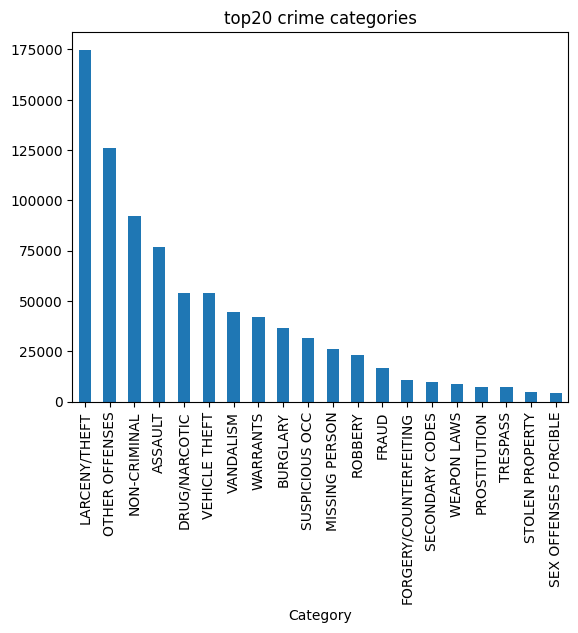

In [60]:
# EDA
import pandas as pd
url='D:/0python_SNC/15pandas/pandas-data-analysis-main/part7/data/San-Francisco-Crime .csv'
df=pd.read_csv(url)
df.head()
print(df.isna().mean().sort_values(ascending=False))

# top categories
import matplotlib.pyplot as plt
df.Category.value_counts().head(20).plot(kind='bar')
plt.title('top20 crime categories')
plt.show()

Text(0.5, 1.0, 'crime per month')

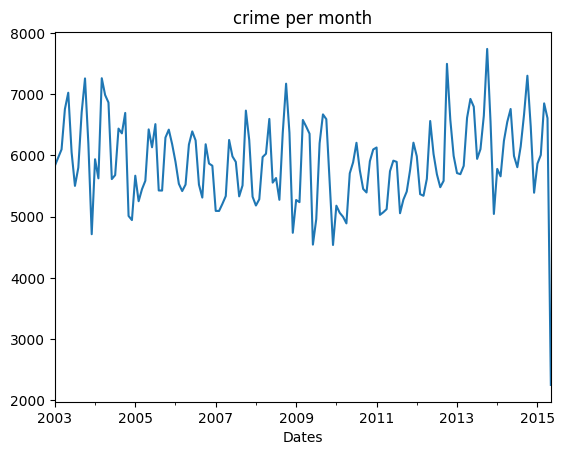

In [61]:
# 월별 트랜드
dt = pd.to_datetime(df.Dates)
monthly= df.groupby([dt.dt.to_period('M')]).size().rename('count').to_timestamp()
monthly.plot()
plt.title('crime per month')

Text(0.5, 1.0, 'crime per hour')

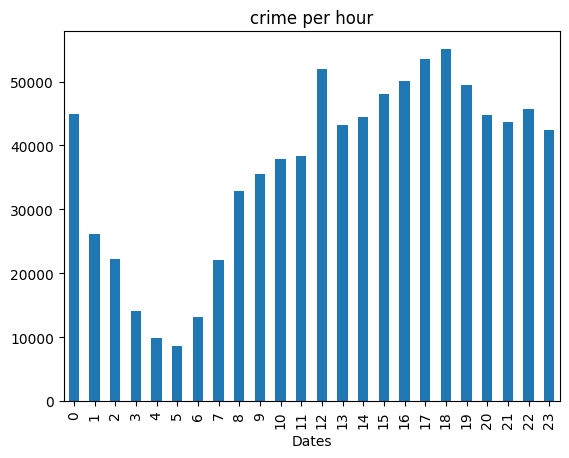

In [62]:
# 시간대
dt.dt.hour.value_counts().sort_index().plot(kind='bar')
plt.title('crime per hour')

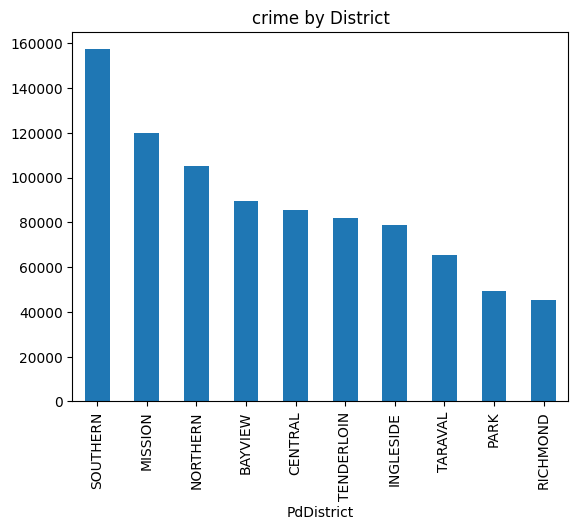

In [63]:
# District counts
df.PdDistrict.value_counts().head(15).plot(kind='bar')
plt.title('crime by District')
plt.show()

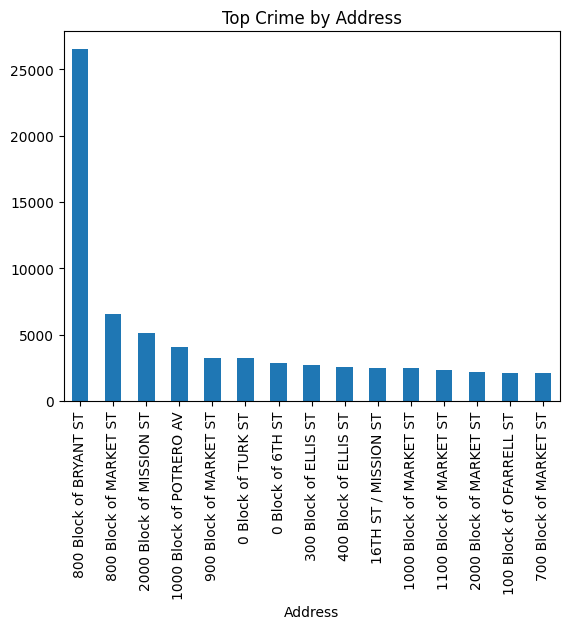

In [64]:
# top address
df.Address.value_counts().head(15).plot(kind='bar')
plt.title('Top Crime by Address')
plt.show()

In [65]:
# Feature Engineering
import numpy as np
out = df.copy()
dt = pd.to_datetime(out.Dates)
out['Year']= dt.dt.year.astype(np.int16)
out['Month']= dt.dt.month.astype(np.int8)
out['Day']= dt.dt.day.astype(np.int8)
out['Hour']= dt.dt.hour.astype(np.int8)  
out['Minute']= dt.dt.minute.astype(np.int8)
out['isWeekend']= (dt.dt.dayofweek >=5).astype(np.int8)

# 시간/요일 전처리
# 시간정보 => 직선형태로 인식하므로.. 23시와0시를 1시간이 아닌 23차이로.. 그래서 서클형태로 만들어줘야함. 
# 시간/요일 정보 시계처럼 2차원 원으로 표현
# 1. 데이터를 각도로 변환 [] 2*np.pi*시간/24.0 ] ==> 0~23시를 360도 원의 각도로 변환 ==> 6시 90도, 12시 180도
# 2. 좌표를 계산 : cosine, sine 

# 시간 좌표
out['sin_hour'] = np.sin(2*np.pi*out.Hour/24.0).astype(np.float32)
out['cos_hour'] = np.cos(2*np.pi*out.Hour/24.0).astype(np.float32)
# 요일 좌표
mask={'Monday' : 0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4, 'Saturday':5, 'Sunday':6}
out['dow_idx']=out.DayOfWeek.map(mask).astype(np.int8)
out['sin_dow'] =np.sin(2*np.pi*out.dow_idx/7.0).astype(np.float32)
out['cos_dow'] = np.cos(2*np.pi*out.dow_idx/7.0).astype(np.float32)


# 주소 전처리
out['HasBlock'] = out.Address.str.contains('Block', case=False, regex=False).astype(np.int8) #case=False 대소문자 구분없이

# X,Y 전처리
new_center_x = -122.391846
new_center_y = 37.778125
# 지구둘레 40,000(지구둘레)/360 = 111.1 km  ==> 1 degree = 111.0 km 로 계산
dx = (out.X - new_center_x)*(111.0*np.cos(np.deg2rad(new_center_y)))
dy = (out.Y - new_center_y)*(111.0)
# 거리
out['dist_km_new_center'] = np.sqrt(dx*dx + dy*dy).astype(np.float32)

out['x_round2'] = out.X.round(2).astype(np.float32)
out['y_round2'] = out.Y.round(2).astype(np.float32)




In [66]:
out.head()
out.columns

Index(['Dates', 'Category', 'Descript', 'DayOfWeek', 'PdDistrict',
       'Resolution', 'Address', 'X', 'Y', 'Year', 'Month', 'Day', 'Hour',
       'Minute', 'isWeekend', 'sin_hour', 'cos_hour', 'dow_idx', 'sin_dow',
       'cos_dow', 'HasBlock', 'dist_km_new_center', 'x_round2', 'y_round2'],
      dtype='object')

In [70]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(out.Category)
class_names = le.classes_
len(class_names)
category_cols = ['PdDistrict','isWeekend','HasBlock' ]
numeric_cols = [ 'Year', 'Month', 'Day', 'Hour',
       'Minute', 'sin_hour', 'cos_hour', 'dow_idx', 'sin_dow',
       'cos_dow', 'dist_km_new_center', 'x_round2', 'y_round2']
x_df = out[category_cols + numeric_cols]
x_df
# 데이터 분류
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x_df, y, test_size=0.2, stratify=y, random_state=42)

In [71]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False) #결측치 무시? handle_unknown='ignore'
xtr_cat = ohe.fit_transform (X_train[category_cols]) #컬럼 14개로 변경
xte_cat = ohe.transform(X_test[category_cols])
scaler = StandardScaler()
xtr_num = scaler.fit_transform(X_train[numeric_cols]).astype(np.float32)  #머신러닝은 정수보다 실수형태를 더 정확하게 계산함 astype(np.float32)
xte_num = scaler.transform(X_test[numeric_cols]).astype(np.float32)

x_train_ = np.hstack([xtr_cat, xtr_num]).astype(np.float32)
x_test_ = np.hstack ([xte_cat, xte_num]).astype(np.float32)

In [72]:
# 클래스 불균형 해소? : 확률적 경사하강법 - 미분개념 .. 기울기 .. 학습.. 학습오차..  
from sklearn.linear_model import SGDClassifier
# linearSVM 과 동일한 방식
svm_over = SGDClassifier(
    class_weight='balanced',
    n_jobs= -1,
    random_state=42
)
# svm 기본 출력은 확률이 아니라, 결정경계로부터 얼마나 멀리 떨어져 있는지 나타내는 점수 또는 거리
svm_over.fit(x_train_, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,-1


In [73]:
svm_over.score(x_test_,y_test)
# 결과값 안좋음...  0.07685780991970845

0.07685780991970845

In [ ]:
%pip install lightgbm

In [74]:
# 다른 모델 적용
from lightgbm import LGBMClassifier
lgbm=LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
lgbm.fit(x_train_, y_train)
lgbm.score(x_test_, y_test)

d:\0python_SNC\streamlit_prj\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.15277034337452308

In [ ]:
### 다음시간 (10/17) to do 
# 범죄유형별로 모델 만들기 one vs reset
# 다중 클래스모델을 정교화 - 모든 범죄유형을 한번에 분류 .. 불균형 문제를 효과적으로 